In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Operator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.compiler import transpile
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_aer.primitives import SamplerV2
from qiskit_aer import AerSimulator
from matplotlib import pyplot as plt
from qiskit.circuit.library import RealAmplitudes
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import UnitaryGate
import numpy as np
import matplotlib.ticker as ticker
from scipy.linalg import svd
from qiskit.quantum_info import Statevector


In [2]:
simulator = AerSimulator()

Deviation from identity: 3.597533769998862e-16


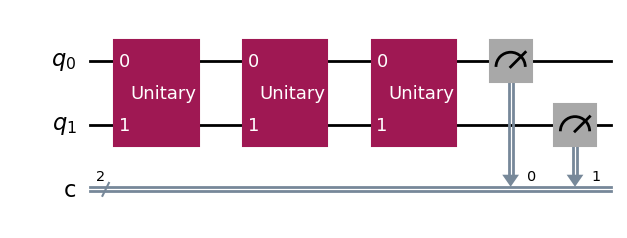

In [14]:
# Define mixing angles (in radians) and CP phase

theta_12, theta_13, theta_23 = np.radians([33.68, 8.56, 43.3])  # nu-fit values for NH
delta_CP = np.radians(0)

# Define the PMNS matrix
# Define the PMNS matrix and embed it in a 4x4 unitary
def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP)

    # 3x3 PMNS matrix
    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_idelta, c12 * c23 - s12 * s23 * s13 * e_idelta, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_idelta, -c12 * s23 - s12 * c23 * s13 * e_idelta, c23 * c13]
    ], dtype=complex)

    # Embed in 4x4 matrix
    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[np.ix_([0,1,2],[0,1,2])] = U  # Transpose for Qiskit's column convention
    return U_4x4
# Compute U_PMNS and its Hermitian conjugate
U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
# Project U_PMNS_4x4 to the nearest unitary to ensure numerical stability

def project_to_unitary(U):
    U_svd, _, Vh = svd(U)
    return U_svd @ Vh

U_PMNS_4x4 = project_to_unitary(U_PMNS_4x4)
U_PMNS_dagger_4x4 = U_PMNS_4x4.conj().T
unitarity_check = U_PMNS_dagger_4x4 @ U_PMNS_4x4
print("Deviation from identity:", np.linalg.norm(unitarity_check - np.eye(4)))



# Lists to store energy values and probabilities
E_list = []
P_nue_list = []
P_numu_list = []
P_nutau_list = []
E_values = np.arange(0.01, 5, 0.01)  # GeV
E=E_values[0]
# Create the quantum circuit
qc = QuantumCircuit(2, 2)

# STEP 1: Initialize mass=flavour state before mixing
initial_state = 'e'  # Choose 'e', 'mu', or 'tau'
if initial_state == 'e':
    pass
elif initial_state == 'mu':
    qc.x(1)  # |01> = ν_2=nu_mu
elif initial_state == 'tau':
    qc.x(0)  # |10> = ν_3=nu_tau

# STEP 2: Apply PMNS (write flavour state in mass basis)
qc.unitary(UnitaryGate(U_PMNS_4x4.T, label="U_PMNS"), [0, 1])
#nu_mu_state = U_PMNS_4x4[:, 1] / np.linalg.norm(U_PMNS_4x4[:, 1])  # Normalize state
#qc.initialize(nu_mu_state, [0, 1])


#state = Statevector.from_instruction(qc)
#print(state)

# STEP 3: Apply time evolution in mass basis
sDm2 = 7.49e-5  # Delta_21 in eV^2
lDm2 = 2.513e-3  # Delta_31 in eV^2
hbar = 6.582e-16  # eV·s
c = 3e8  # m/s
L = 810*1e3  # NOvA baseline in meters
t = L / c  # time in seconds 
#print(t)

# Convert mass-squared differences into angular frequencies
omega0=0
omega1 = sDm2 / (2 * E * 1e9 * hbar)  # rad/s
#print (2*omega1*t)
omega2 = lDm2 / (2 * E * 1e9 * hbar)  # rad/s
#print(2*omega2*t)
# Build time evolution operator: diag(1, e^{-iΔ21 t}, e^{-iΔ31 t}, 1)
evolution = np.eye(4, dtype=complex)
evolution[1, 1] = np.exp(-1j * omega1 * t)  # |01⟩ = ν_2
#print(evolution[1, 1])
evolution[2, 2] = np.exp(-1j * omega2 * t)  # |10⟩ = ν_3
#print(evolution[2, 2])
U_evolution = UnitaryGate(evolution.T, label="e^(-iHt)")
qc.unitary(U_evolution, [0, 1])
#qc.rz(2* omega0 * t, 0)  # Phase rotation for |ν_1>
#qc.rz(2* omega1 * t, 1)  # Phase rotation for |ν_2>
#qc.rz(2* omega2 * t, 0)  # Phase rotation for |ν_3>
#state = Statevector.from_instruction(qc)
#print(state)
#print("Row representation:", U_PMNS_4x4[0, :])
# STEP 4: Apply U_PMNS† to rotate back to flavour basis
qc.unitary(UnitaryGate(U_PMNS_dagger_4x4.T, label="U_PMNS†"), [0, 1])
#state = Statevector.from_instruction(qc)
#print(state)
qc.measure([0, 1], [0, 1])
    

# Draw circuit
qc.draw('mpl')


Deviation from identity: 3.597533769998862e-16


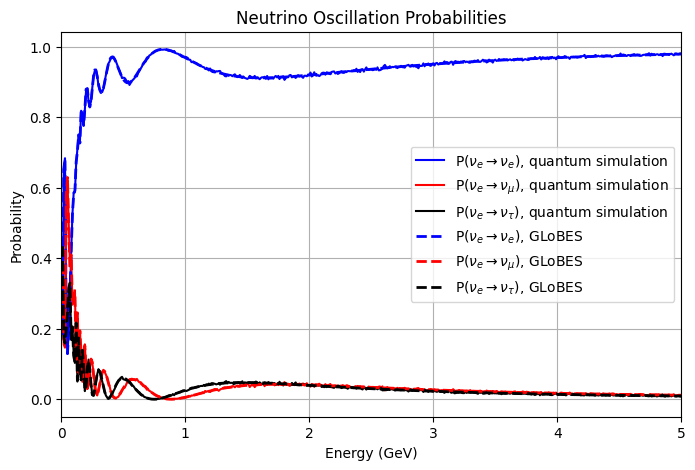

In [13]:
# Define mixing angles (in radians) and CP phase

theta_12, theta_13, theta_23 = np.radians([33.68, 8.56, 43.3])  # nu-fit values for NH
delta_CP = np.radians(0)

# Define the PMNS matrix
# Define the PMNS matrix and embed it in a 4x4 unitary
def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP)

    # 3x3 PMNS matrix
    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_idelta, c12 * c23 - s12 * s23 * s13 * e_idelta, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_idelta, -c12 * s23 - s12 * c23 * s13 * e_idelta, c23 * c13]
    ], dtype=complex)

    # Embed in 4x4 matrix
    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[np.ix_([0,1,2],[0,1,2])] = U  # Transpose for Qiskit's column convention
    return U_4x4
# Compute U_PMNS and its Hermitian conjugate
U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
# Project U_PMNS_4x4 to the nearest unitary to ensure numerical stability

def project_to_unitary(U):
    U_svd, _, Vh = svd(U)
    return U_svd @ Vh

U_PMNS_4x4 = project_to_unitary(U_PMNS_4x4)
U_PMNS_dagger_4x4 = U_PMNS_4x4.conj().T
unitarity_check = U_PMNS_dagger_4x4 @ U_PMNS_4x4
print("Deviation from identity:", np.linalg.norm(unitarity_check - np.eye(4)))



# Lists to store energy values and probabilities
E_list = []
P_nue_list = []
P_numu_list = []
P_nutau_list = []
E_values = np.arange(0.01, 5, 0.01)  # GeV
for E in E_values:
    # Create the quantum circuit
    qc = QuantumCircuit(2, 2)

    # STEP 1: Initialize mass=flavour state before mixing
    initial_state = 'e'  # Choose 'e', 'mu', or 'tau'
    if initial_state == 'e':
        pass
    elif initial_state == 'mu':
        qc.x(1)  # |01> = ν_2=nu_mu
    elif initial_state == 'tau':
        qc.x(0)  # |10> = ν_3=nu_tau

    # STEP 2: Apply PMNS (write flavour state in mass basis)
    qc.unitary(UnitaryGate(U_PMNS_4x4.T, label="U_PMNS"), [0, 1])
    #nu_mu_state = U_PMNS_4x4[:, 1] / np.linalg.norm(U_PMNS_4x4[:, 1])  # Normalize state
    #qc.initialize(nu_mu_state, [0, 1])


    #state = Statevector.from_instruction(qc)
    #print(state)

    # STEP 3: Apply time evolution in mass basis
    sDm2 = 7.49e-5  # Delta_21 in eV^2
    lDm2 = 2.513e-3  # Delta_31 in eV^2
    hbar = 6.582e-16  # eV·s
    c = 3e8  # m/s
    L = 810*1e3  # NOvA baseline in meters
    t = L / c  # time in seconds
    #print(t)

# Convert mass-squared differences into angular frequencies
    omega0=0
    omega1 = sDm2 / (2 * E * 1e9 * hbar)  # rad/s
    #print (2*omega1*t)
    omega2 = lDm2 / (2 * E * 1e9 * hbar)  # rad/s
    #print(2*omega2*t)
    # Build time evolution operator: diag(1, e^{-iΔ21 t}, e^{-iΔ31 t}, 1)
    evolution = np.eye(4, dtype=complex)
    evolution[1, 1] = np.exp(-1j * omega1 * t)  # |01⟩ = ν_2
    #print(evolution[1, 1])
    evolution[2, 2] = np.exp(-1j * omega2 * t)  # |10⟩ = ν_3
    #print(evolution[2, 2])
    U_evolution = UnitaryGate(evolution.T, label="e^(-iHt)")
    qc.unitary(U_evolution, [0, 1])
#qc.rz(2* omega0 * t, 0)  # Phase rotation for |ν_1>
#qc.rz(2* omega1 * t, 1)  # Phase rotation for |ν_2>
#qc.rz(2* omega2 * t, 0)  # Phase rotation for |ν_3>
    #state = Statevector.from_instruction(qc)
    #print(state)
    #print("Row representation:", U_PMNS_4x4[0, :])
    # STEP 4: Apply U_PMNS† to rotate back to flavour basis
    qc.unitary(UnitaryGate(U_PMNS_dagger_4x4.T, label="U_PMNS†"), [0, 1])
    #state = Statevector.from_instruction(qc)
    #print(state)
    qc.measure([0, 1], [0, 1])
    pqc = transpile(qc, simulator)
    job = simulator.run(qc, shots=8192)
    job_result = job.result()
    counts = job_result.get_counts()
    total_counts = sum([counts.get(state, 0) for state in ['00', '01', '10']])  # Sum over 3 relevant states
    #print(total_counts)
    ###### The following two lines print energy and both nu_e and nu_mu probabilities########
    probability = {state: count / 1024 for state, count in counts.items()}
    #print(f"E = {E :.2f} GeV -> Probability: {probability}")
    probability_nue = counts.get('00', 0) / (total_counts)  # nu_e-->nu_e survival probability
    probability_nutau = counts.get('10', 0) / total_counts  # nu_e-->nu_tau oscillation probability
    probability_numu = counts.get('01', 0) / total_counts # nu_e-->nu_mu oscillation probability
    #print(E, probability_nue, probability_numu, probability_nutau)
    E_list.append(E)
    P_nue_list.append(probability_nue)
    P_numu_list.append(probability_numu)
    P_nutau_list.append(probability_nutau)
# Load the classical GLoBES results from the file
glb_E, glb_P_nue, glb_P_numu, glb_P_nutau = np.loadtxt("prob_nue_numu_nova_initial_nue.dat", unpack=True)

# Plot the probabilities
plt.figure(figsize=(8, 5))

# Plot quantum simulation results
plt.plot(E_list, P_nue_list, label=r'P($\nu_e \to \nu_e$), quantum simulation', linestyle='-', color='blue')
plt.plot(E_list, P_numu_list, label=r'P($\nu_e \to \nu_\mu$), quantum simulation', linestyle='-', color='red')
plt.plot(E_list, P_nutau_list, label=r'P($\nu_e \to \nu_\tau$), quantum simulation', linestyle='-', color='black')
# Plot classical GLoBES results from the data file
plt.plot(glb_E, glb_P_nue, linestyle='--', color='blue', linewidth=2, label=r'P($\nu_e \to \nu_e$), GLoBES')
plt.plot(glb_E, glb_P_numu, linestyle='--', color='red', linewidth=2, label=r'P($\nu_e \to \nu_\mu$), GLoBES')
plt.plot(glb_E, glb_P_nutau, linestyle='--', color='black', linewidth=2, label=r'P($\nu_e \to \nu_\tau$), GLoBES')
# Fix the x-axis range
plt.xlim(0, 5)  # Set range explicitly

# Labels and title
plt.xlabel("Energy (GeV)")
plt.ylabel("Probability")
plt.title("Neutrino Oscillation Probabilities")
plt.legend()
plt.grid()
plt.show()

Deviation from identity: 3.597533769998862e-16


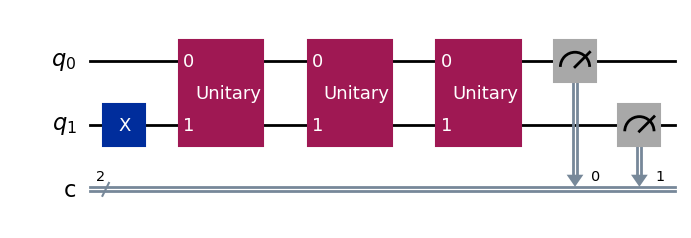

In [15]:
# Define mixing angles (in radians) and CP phase

theta_12, theta_13, theta_23 = np.radians([33.68, 8.56, 43.3])  # nu-fit values for NH
delta_CP = np.radians(0)

# Define the PMNS matrix
# Define the PMNS matrix and embed it in a 4x4 unitary
def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP)

    # 3x3 PMNS matrix
    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_idelta, c12 * c23 - s12 * s23 * s13 * e_idelta, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_idelta, -c12 * s23 - s12 * c23 * s13 * e_idelta, c23 * c13]
    ], dtype=complex)

    # Embed in 4x4 matrix
    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[np.ix_([0,1,2],[0,1,2])] = U  # Transpose for Qiskit's column convention
    return U_4x4
# Compute U_PMNS and its Hermitian conjugate
U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
# Project U_PMNS_4x4 to the nearest unitary to ensure numerical stability

def project_to_unitary(U):
    U_svd, _, Vh = svd(U)
    return U_svd @ Vh

U_PMNS_4x4 = project_to_unitary(U_PMNS_4x4)
U_PMNS_dagger_4x4 = U_PMNS_4x4.conj().T
unitarity_check = U_PMNS_dagger_4x4 @ U_PMNS_4x4
print("Deviation from identity:", np.linalg.norm(unitarity_check - np.eye(4)))



# Lists to store energy values and probabilities
E_list = []
P_nue_list = []
P_numu_list = []
P_nutau_list = []
E_values = np.arange(0.01, 5, 0.01)  # GeV
E=E_values[0]
# Create the quantum circuit
qc = QuantumCircuit(2, 2)

# STEP 1: Initialize mass=flavour state before mixing
initial_state = 'mu'  # Choose 'e', 'mu', or 'tau'
if initial_state == 'e':
    pass
elif initial_state == 'mu':
    qc.x(1)  # |01> = ν_2=nu_mu
elif initial_state == 'tau':
    qc.x(0)  # |10> = ν_3=nu_tau

# STEP 2: Apply PMNS (write flavour state in mass basis)
qc.unitary(UnitaryGate(U_PMNS_4x4.T, label="U_PMNS"), [0, 1])
#nu_mu_state = U_PMNS_4x4[:, 1] / np.linalg.norm(U_PMNS_4x4[:, 1])  # Normalize state
#qc.initialize(nu_mu_state, [0, 1])


#state = Statevector.from_instruction(qc)
#print(state)

# STEP 3: Apply time evolution in mass basis
sDm2 = 7.49e-5  # Delta_21 in eV^2
lDm2 = 2.513e-3  # Delta_31 in eV^2
hbar = 6.582e-16  # eV·s
c = 3e8  # m/s
L = 810*1e3  # NOvA baseline in meters
t = L / c  # time in seconds 
#print(t)

# Convert mass-squared differences into angular frequencies
omega0=0
omega1 = sDm2 / (2 * E * 1e9 * hbar)  # rad/s
#print (2*omega1*t)
omega2 = lDm2 / (2 * E * 1e9 * hbar)  # rad/s
#print(2*omega2*t)
# Build time evolution operator: diag(1, e^{-iΔ21 t}, e^{-iΔ31 t}, 1)
evolution = np.eye(4, dtype=complex)
evolution[1, 1] = np.exp(-1j * omega1 * t)  # |01⟩ = ν_2
#print(evolution[1, 1])
evolution[2, 2] = np.exp(-1j * omega2 * t)  # |10⟩ = ν_3
#print(evolution[2, 2])
U_evolution = UnitaryGate(evolution.T, label="e^(-iHt)")
qc.unitary(U_evolution, [0, 1])
#qc.rz(2* omega0 * t, 0)  # Phase rotation for |ν_1>
#qc.rz(2* omega1 * t, 1)  # Phase rotation for |ν_2>
#qc.rz(2* omega2 * t, 0)  # Phase rotation for |ν_3>
#state = Statevector.from_instruction(qc)
#print(state)
#print("Row representation:", U_PMNS_4x4[0, :])
# STEP 4: Apply U_PMNS† to rotate back to flavour basis
qc.unitary(UnitaryGate(U_PMNS_dagger_4x4.T, label="U_PMNS†"), [0, 1])
#state = Statevector.from_instruction(qc)
#print(state)
qc.measure([0, 1], [0, 1])
    

# Draw circuit
qc.draw('mpl')


Deviation from identity: 3.597533769998862e-16


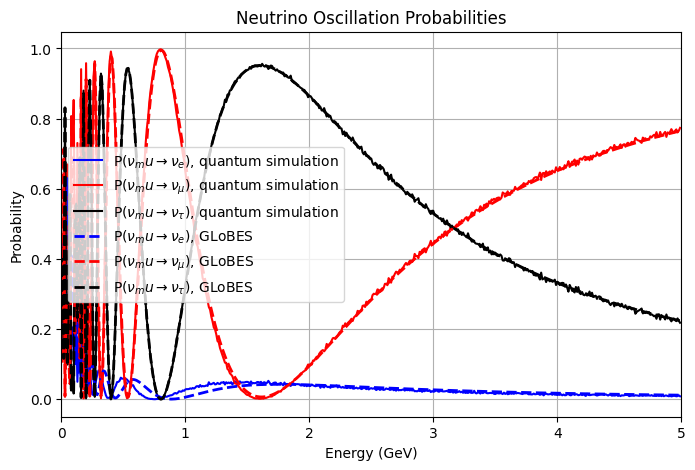

In [19]:
# Define mixing angles (in radians) and CP phase

theta_12, theta_13, theta_23 = np.radians([33.68, 8.56, 43.3])  # nu-fit values for NH
delta_CP = np.radians(0)

# Define the PMNS matrix
# Define the PMNS matrix and embed it in a 4x4 unitary
def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP)

    # 3x3 PMNS matrix
    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_idelta, c12 * c23 - s12 * s23 * s13 * e_idelta, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_idelta, -c12 * s23 - s12 * c23 * s13 * e_idelta, c23 * c13]
    ], dtype=complex)

    # Embed in 4x4 matrix
    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[np.ix_([0,1,2],[0,1,2])] = U  # Transpose for Qiskit's column convention
    return U_4x4
# Compute U_PMNS and its Hermitian conjugate
U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
# Project U_PMNS_4x4 to the nearest unitary to ensure numerical stability

def project_to_unitary(U):
    U_svd, _, Vh = svd(U)
    return U_svd @ Vh

U_PMNS_4x4 = project_to_unitary(U_PMNS_4x4)
U_PMNS_dagger_4x4 = U_PMNS_4x4.conj().T
unitarity_check = U_PMNS_dagger_4x4 @ U_PMNS_4x4
print("Deviation from identity:", np.linalg.norm(unitarity_check - np.eye(4)))



# Lists to store energy values and probabilities
E_list = []
P_nue_list = []
P_numu_list = []
P_nutau_list = []
E_values = np.arange(0.01, 5, 0.01)  # GeV
for E in E_values:
    # Create the quantum circuit
    qc = QuantumCircuit(2, 2)

    # STEP 1: Initialize mass=flavour state before mixing
    initial_state = 'mu'  # Choose 'e', 'mu', or 'tau'
    if initial_state == 'e':
        pass
    elif initial_state == 'mu':
        qc.x(1)  # |01> = ν_2=nu_mu
    elif initial_state == 'tau':
        qc.x(0)  # |10> = ν_3=nu_tau

    # STEP 2: Apply PMNS (write flavour state in mass basis)
    qc.unitary(UnitaryGate(U_PMNS_4x4.T, label="U_PMNS"), [0, 1])
    #nu_mu_state = U_PMNS_4x4[:, 1] / np.linalg.norm(U_PMNS_4x4[:, 1])  # Normalize state
    #qc.initialize(nu_mu_state, [0, 1])


    #state = Statevector.from_instruction(qc)
    #print(state)

    # STEP 3: Apply time evolution in mass basis
    sDm2 = 7.49e-5  # Delta_21 in eV^2
    lDm2 = 2.513e-3  # Delta_31 in eV^2
    hbar = 6.582e-16  # eV·s
    c = 3e8  # m/s
    L = 810*1e3  # NOvA baseline in meters
    t = L / c  # time in seconds
    #print(t)

# Convert mass-squared differences into angular frequencies
    omega0=0
    omega1 = sDm2 / (2 * E * 1e9 * hbar)  # rad/s
    #print (2*omega1*t)
    omega2 = lDm2 / (2 * E * 1e9 * hbar)  # rad/s
    #print(2*omega2*t)
    # Build time evolution operator: diag(1, e^{-iΔ21 t}, e^{-iΔ31 t}, 1)
    evolution = np.eye(4, dtype=complex)
    evolution[1, 1] = np.exp(-1j * omega1 * t)  # |01⟩ = ν_2
    #print(evolution[1, 1])
    evolution[2, 2] = np.exp(-1j * omega2 * t)  # |10⟩ = ν_3
    #print(evolution[2, 2])
    U_evolution = UnitaryGate(evolution.T, label="e^(-iHt)")
    qc.unitary(U_evolution, [0, 1])
#qc.rz(2* omega0 * t, 0)  # Phase rotation for |ν_1>
#qc.rz(2* omega1 * t, 1)  # Phase rotation for |ν_2>
#qc.rz(2* omega2 * t, 0)  # Phase rotation for |ν_3>
    #state = Statevector.from_instruction(qc)
    #print(state)
    #print("Row representation:", U_PMNS_4x4[0, :])
    # STEP 4: Apply U_PMNS† to rotate back to flavour basis
    qc.unitary(UnitaryGate(U_PMNS_dagger_4x4.T, label="U_PMNS†"), [0, 1])
    #state = Statevector.from_instruction(qc)
    #print(state)
    qc.measure([0, 1], [0, 1])
    pqc = transpile(qc, simulator)
    job = simulator.run(qc, shots=8192)
    job_result = job.result()
    counts = job_result.get_counts()
    total_counts = sum([counts.get(state, 0) for state in ['00', '01', '10']])  # Sum over 3 relevant states
    #print(total_counts)
    ###### The following two lines print energy and both nu_e and nu_mu probabilities########
    probability = {state: count / 1024 for state, count in counts.items()}
    #print(f"E = {E :.2f} GeV -> Probability: {probability}")
    probability_nue = counts.get('00', 0) / (total_counts)  # nu_mu-->nu_e survival probability
    probability_nutau = counts.get('01', 0) / total_counts  # nu_mu-->nu_tau oscillation probability
    probability_numu = counts.get('10', 0) / total_counts # nu_mu-->nu_mu oscillation probability
    #print(E, probability_nue, probability_numu, probability_nutau)
    E_list.append(E)
    P_nue_list.append(probability_nue)
    P_numu_list.append(probability_numu)
    P_nutau_list.append(probability_nutau)
# Load the classical GLoBES results from the file
glb_E, glb_P_nue, glb_P_numu, glb_P_nutau = np.loadtxt("prob_nue_numu_nova.dat", unpack=True)

# Plot the probabilities
plt.figure(figsize=(8, 5))

# Plot quantum simulation results
plt.plot(E_list, P_nue_list, label=r'P($\nu_mu \to \nu_e$), quantum simulation', linestyle='-', color='blue')
plt.plot(E_list, P_numu_list, label=r'P($\nu_mu \to \nu_\mu$), quantum simulation', linestyle='-', color='red')
plt.plot(E_list, P_nutau_list, label=r'P($\nu_mu \to \nu_\tau$), quantum simulation', linestyle='-', color='black')
# Plot classical GLoBES results from the data file
plt.plot(glb_E, glb_P_nue, linestyle='--', color='blue', linewidth=2, label=r'P($\nu_mu \to \nu_e$), GLoBES')
plt.plot(glb_E, glb_P_numu, linestyle='--', color='red', linewidth=2, label=r'P($\nu_mu \to \nu_\mu$), GLoBES')
plt.plot(glb_E, glb_P_nutau, linestyle='--', color='black', linewidth=2, label=r'P($\nu_mu \to \nu_\tau$), GLoBES')
# Fix the x-axis range
plt.xlim(0, 5)  # Set range explicitly

# Labels and title
plt.xlabel("Energy (GeV)")
plt.ylabel("Probability")
plt.title("Neutrino Oscillation Probabilities")
plt.legend()
plt.grid()
plt.show()

Deviation from identity: 3.597533769998862e-16


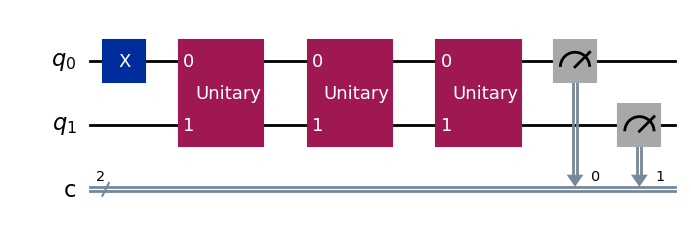

In [20]:
# Define mixing angles (in radians) and CP phase

theta_12, theta_13, theta_23 = np.radians([33.68, 8.56, 43.3])  # nu-fit values for NH
delta_CP = np.radians(0)

# Define the PMNS matrix
# Define the PMNS matrix and embed it in a 4x4 unitary
def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP)

    # 3x3 PMNS matrix
    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_idelta, c12 * c23 - s12 * s23 * s13 * e_idelta, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_idelta, -c12 * s23 - s12 * c23 * s13 * e_idelta, c23 * c13]
    ], dtype=complex)

    # Embed in 4x4 matrix
    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[np.ix_([0,1,2],[0,1,2])] = U  # Transpose for Qiskit's column convention
    return U_4x4
# Compute U_PMNS and its Hermitian conjugate
U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
# Project U_PMNS_4x4 to the nearest unitary to ensure numerical stability

def project_to_unitary(U):
    U_svd, _, Vh = svd(U)
    return U_svd @ Vh

U_PMNS_4x4 = project_to_unitary(U_PMNS_4x4)
U_PMNS_dagger_4x4 = U_PMNS_4x4.conj().T
unitarity_check = U_PMNS_dagger_4x4 @ U_PMNS_4x4
print("Deviation from identity:", np.linalg.norm(unitarity_check - np.eye(4)))



# Lists to store energy values and probabilities
E_list = []
P_nue_list = []
P_numu_list = []
P_nutau_list = []
E_values = np.arange(0.01, 5, 0.01)  # GeV
E=E_values[0]
# Create the quantum circuit
qc = QuantumCircuit(2, 2)

# STEP 1: Initialize mass=flavour state before mixing
initial_state = 'tau'  # Choose 'e', 'mu', or 'tau'
if initial_state == 'e':
    pass
elif initial_state == 'mu':
    qc.x(1)  # |01> = ν_2=nu_mu
elif initial_state == 'tau':
    qc.x(0)  # |10> = ν_3=nu_tau

# STEP 2: Apply PMNS (write flavour state in mass basis)
qc.unitary(UnitaryGate(U_PMNS_4x4.T, label="U_PMNS"), [0, 1])
#nu_mu_state = U_PMNS_4x4[:, 1] / np.linalg.norm(U_PMNS_4x4[:, 1])  # Normalize state
#qc.initialize(nu_mu_state, [0, 1])


#state = Statevector.from_instruction(qc)
#print(state)

# STEP 3: Apply time evolution in mass basis
sDm2 = 7.49e-5  # Delta_21 in eV^2
lDm2 = 2.513e-3  # Delta_31 in eV^2
hbar = 6.582e-16  # eV·s
c = 3e8  # m/s
L = 810*1e3  # NOvA baseline in meters
t = L / c  # time in seconds 
#print(t)

# Convert mass-squared differences into angular frequencies
omega0=0
omega1 = sDm2 / (2 * E * 1e9 * hbar)  # rad/s
#print (2*omega1*t)
omega2 = lDm2 / (2 * E * 1e9 * hbar)  # rad/s
#print(2*omega2*t)
# Build time evolution operator: diag(1, e^{-iΔ21 t}, e^{-iΔ31 t}, 1)
evolution = np.eye(4, dtype=complex)
evolution[1, 1] = np.exp(-1j * omega1 * t)  # |01⟩ = ν_2
#print(evolution[1, 1])
evolution[2, 2] = np.exp(-1j * omega2 * t)  # |10⟩ = ν_3
#print(evolution[2, 2])
U_evolution = UnitaryGate(evolution.T, label="e^(-iHt)")
qc.unitary(U_evolution, [0, 1])
#qc.rz(2* omega0 * t, 0)  # Phase rotation for |ν_1>
#qc.rz(2* omega1 * t, 1)  # Phase rotation for |ν_2>
#qc.rz(2* omega2 * t, 0)  # Phase rotation for |ν_3>
#state = Statevector.from_instruction(qc)
#print(state)
#print("Row representation:", U_PMNS_4x4[0, :])
# STEP 4: Apply U_PMNS† to rotate back to flavour basis
qc.unitary(UnitaryGate(U_PMNS_dagger_4x4.T, label="U_PMNS†"), [0, 1])
#state = Statevector.from_instruction(qc)
#print(state)
qc.measure([0, 1], [0, 1])
    

# Draw circuit
qc.draw('mpl')


Deviation from identity: 3.597533769998862e-16


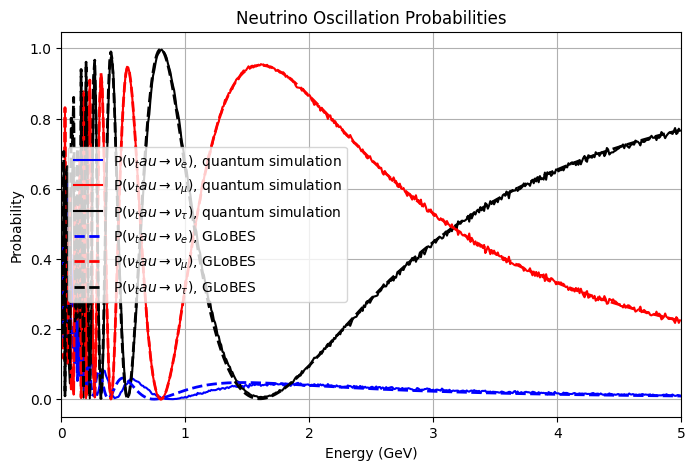

In [21]:
# Define mixing angles (in radians) and CP phase

theta_12, theta_13, theta_23 = np.radians([33.68, 8.56, 43.3])  # nu-fit values for NH
delta_CP = np.radians(0)

# Define the PMNS matrix
# Define the PMNS matrix and embed it in a 4x4 unitary
def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP)

    # 3x3 PMNS matrix
    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_idelta, c12 * c23 - s12 * s23 * s13 * e_idelta, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_idelta, -c12 * s23 - s12 * c23 * s13 * e_idelta, c23 * c13]
    ], dtype=complex)

    # Embed in 4x4 matrix
    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[np.ix_([0,1,2],[0,1,2])] = U  # Transpose for Qiskit's column convention
    return U_4x4
# Compute U_PMNS and its Hermitian conjugate
U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
# Project U_PMNS_4x4 to the nearest unitary to ensure numerical stability

def project_to_unitary(U):
    U_svd, _, Vh = svd(U)
    return U_svd @ Vh

U_PMNS_4x4 = project_to_unitary(U_PMNS_4x4)
U_PMNS_dagger_4x4 = U_PMNS_4x4.conj().T
unitarity_check = U_PMNS_dagger_4x4 @ U_PMNS_4x4
print("Deviation from identity:", np.linalg.norm(unitarity_check - np.eye(4)))



# Lists to store energy values and probabilities
E_list = []
P_nue_list = []
P_numu_list = []
P_nutau_list = []
E_values = np.arange(0.01, 5, 0.01)  # GeV
for E in E_values:
    # Create the quantum circuit
    qc = QuantumCircuit(2, 2)

    # STEP 1: Initialize mass=flavour state before mixing
    initial_state = 'tau'  # Choose 'e', 'mu', or 'tau'
    if initial_state == 'e':
        pass
    elif initial_state == 'mu':
        qc.x(1)  # |01> = ν_2=nu_mu
    elif initial_state == 'tau':
        qc.x(0)  # |10> = ν_3=nu_tau

    # STEP 2: Apply PMNS (write flavour state in mass basis)
    qc.unitary(UnitaryGate(U_PMNS_4x4.T, label="U_PMNS"), [0, 1])
    #nu_mu_state = U_PMNS_4x4[:, 1] / np.linalg.norm(U_PMNS_4x4[:, 1])  # Normalize state
    #qc.initialize(nu_mu_state, [0, 1])


    #state = Statevector.from_instruction(qc)
    #print(state)

    # STEP 3: Apply time evolution in mass basis
    sDm2 = 7.49e-5  # Delta_21 in eV^2
    lDm2 = 2.513e-3  # Delta_31 in eV^2
    hbar = 6.582e-16  # eV·s
    c = 3e8  # m/s
    L = 810*1e3  # NOvA baseline in meters
    t = L / c  # time in seconds
    #print(t)

# Convert mass-squared differences into angular frequencies
    omega0=0
    omega1 = sDm2 / (2 * E * 1e9 * hbar)  # rad/s
    #print (2*omega1*t)
    omega2 = lDm2 / (2 * E * 1e9 * hbar)  # rad/s
    #print(2*omega2*t)
    # Build time evolution operator: diag(1, e^{-iΔ21 t}, e^{-iΔ31 t}, 1)
    evolution = np.eye(4, dtype=complex)
    evolution[1, 1] = np.exp(-1j * omega1 * t)  # |01⟩ = ν_2
    #print(evolution[1, 1])
    evolution[2, 2] = np.exp(-1j * omega2 * t)  # |10⟩ = ν_3
    #print(evolution[2, 2])
    U_evolution = UnitaryGate(evolution.T, label="e^(-iHt)")
    qc.unitary(U_evolution, [0, 1])
#qc.rz(2* omega0 * t, 0)  # Phase rotation for |ν_1>
#qc.rz(2* omega1 * t, 1)  # Phase rotation for |ν_2>
#qc.rz(2* omega2 * t, 0)  # Phase rotation for |ν_3>
    #state = Statevector.from_instruction(qc)
    #print(state)
    #print("Row representation:", U_PMNS_4x4[0, :])
    # STEP 4: Apply U_PMNS† to rotate back to flavour basis
    qc.unitary(UnitaryGate(U_PMNS_dagger_4x4.T, label="U_PMNS†"), [0, 1])
    #state = Statevector.from_instruction(qc)
    #print(state)
    qc.measure([0, 1], [0, 1])
    pqc = transpile(qc, simulator)
    job = simulator.run(qc, shots=8192)
    job_result = job.result()
    counts = job_result.get_counts()
    total_counts = sum([counts.get(state, 0) for state in ['00', '01', '10']])  # Sum over 3 relevant states
    #print(total_counts)
    ###### The following two lines print energy and both nu_e and nu_mu probabilities########
    probability = {state: count / 1024 for state, count in counts.items()}
    #print(f"E = {E :.2f} GeV -> Probability: {probability}")
    probability_nue = counts.get('00', 0) / (total_counts)  # nu_tau-->nu_e survival probability
    probability_nutau = counts.get('01', 0) / total_counts  # nu_tau-->nu_tau oscillation probability
    probability_numu = counts.get('10', 0) / total_counts # nu_tau-->nu_mu oscillation probability
    #print(E, probability_nue, probability_numu, probability_nutau)
    E_list.append(E)
    P_nue_list.append(probability_nue)
    P_numu_list.append(probability_numu)
    P_nutau_list.append(probability_nutau)
# Load the classical GLoBES results from the file
glb_E, glb_P_nue, glb_P_numu, glb_P_nutau = np.loadtxt("prob_nue_numu_nova_initial_nutau.dat", unpack=True)

# Plot the probabilities
plt.figure(figsize=(8, 5))

# Plot quantum simulation results
plt.plot(E_list, P_nue_list, label=r'P($\nu_tau \to \nu_e$), quantum simulation', linestyle='-', color='blue')
plt.plot(E_list, P_numu_list, label=r'P($\nu_tau \to \nu_\mu$), quantum simulation', linestyle='-', color='red')
plt.plot(E_list, P_nutau_list, label=r'P($\nu_tau \to \nu_\tau$), quantum simulation', linestyle='-', color='black')
# Plot classical GLoBES results from the data file
plt.plot(glb_E, glb_P_nue, linestyle='--', color='blue', linewidth=2, label=r'P($\nu_tau \to \nu_e$), GLoBES')
plt.plot(glb_E, glb_P_numu, linestyle='--', color='red', linewidth=2, label=r'P($\nu_tau \to \nu_\mu$), GLoBES')
plt.plot(glb_E, glb_P_nutau, linestyle='--', color='black', linewidth=2, label=r'P($\nu_tau \to \nu_\tau$), GLoBES')
# Fix the x-axis range
plt.xlim(0, 5)  # Set range explicitly

# Labels and title
plt.xlabel("Energy (GeV)")
plt.ylabel("Probability")
plt.title("Neutrino Oscillation Probabilities")
plt.legend()
plt.grid()
plt.show()